# Агенты в Yandex AI Studio - обзорная лекция

В этой лекции мы рассмотрим основные возможности Yandex AI Studio, и как можно использовать языковые модели Yandex Cloud для построения агентных систем.


Установим необходимые библиотеки:

In [ ]:
%pip install --upgrade openai openai-agents python-dotenv Pillow pyvis networkx

^C
Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.2 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.2 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.2 MB ? eta -:--:--
   --------- ---------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.47.2 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.
gradio 5.47.2 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.
instructor 1.11.3 requires jiter<0.11,>=0.6.1, but you have jiter 0.12.0 which is incompatible.
instructor 1.11.3 requires openai<2.0.0,>=1.70.0, but you have openai 2.31.0 which is incompatible.
langchain-openai 0.3.33 requires openai<2.0.0,>=1.104.2, but you have openai 2.31.0 which is incompatible.


**ВНИМАНИЕ**: После установки библиотек рекомендуется перезапустить Kernel ноутбука.

## Авторизация

Для авторизации в облаке используются специальные значения:

* `folder_id` - это идентификатор облачного каталога
* `api_key` - ключ для доступа к сервисам, который можно сгенерировать в веб-консоли AI Studio

В коде ниже мы предполагаем, что необходимые данные находятся в файле `.env`. Возможно, вам потребуется создать или загрузить файл вручную, или установить значение переменных `folder_id` и `api_key` ниже в программе. 

In [ ]:
!curl -o .env https://storage.yandexcloud.net/pubcourse/.env

In [1]:
import os
import io
import base64
import json
from dotenv import load_dotenv
from PIL import Image as PILImage

load_dotenv()

folder_id = os.environ["folder_id"]
api_key = os.environ["api_key"]

print(f"✅ Авторизация настроена (folder_id: {folder_id[:8]}...)")

✅ Авторизация настроена (folder_id: b1gg3vl8...)


## Работа с LLM через Responses API

Создадим клиент OpenAI SDK для работы с моделями в Yandex Cloud:

In [16]:
from openai import OpenAI

model_qwen = f"gpt://{folder_id}/qwen3.6-35b-a3b/latest"
model_qwen3 = f"gpt://{folder_id}/qwen3-235b-a22b-fp8/latest"
model_deepseek = f"gpt://{folder_id}/deepseek-v32/latest"


client = OpenAI(
    base_url="https://ai.api.cloud.yandex.net/v1",
    api_key=api_key,
    project=folder_id
)

print(f"✅ Клиент создан")

✅ Клиент создан


Обратите внимание, что мы установили свой адрес `base_url` для обращения к модели в облаке Yandex, и использовали специфическое имя модели (содержащее в себе также `folder_id`).

Также добавим вспомогательную функцию для вывода ответа модели в формате Markdown:

In [3]:
from IPython.display import Markdown, display

def printx(string):
    """Вывод текста в формате Markdown."""
    display(Markdown(string))

Responses API — это современный способ взаимодействия с языковой моделью. Он позволяет отправлять запросы и получать ответы, а также поддерживать контекст диалога.

Отправим простой запрос:

In [8]:
concept = "счастье"

res = client.responses.create(
    model=model_deepseek,
    instructions = "Ты - цифровой художник, который готовит промпт для рисовательной модели Yandex ART. По запросу пользователя подумай, как лучше изобразить требуемое, и напиши подробный промпт, но не длиннее 200 символов. Укажи главный объект изображения, стиль рисунка, особые художественные приёмы, чтобы усилить эффект",
    input=f"Нарисуй {concept}"
)

printx(res.output_text)

Яркая акварельная иллюстрация: улыбающееся солнце над цветочным полем, дети обнимаются, развевающиеся волосы, тёплые оранжевые и жёлтые тона, мягкие размытые края, светящиеся блики, ощущение лёгкости и радости.

Для рисования картины можем использовать модель Alice AI ART и Images API:

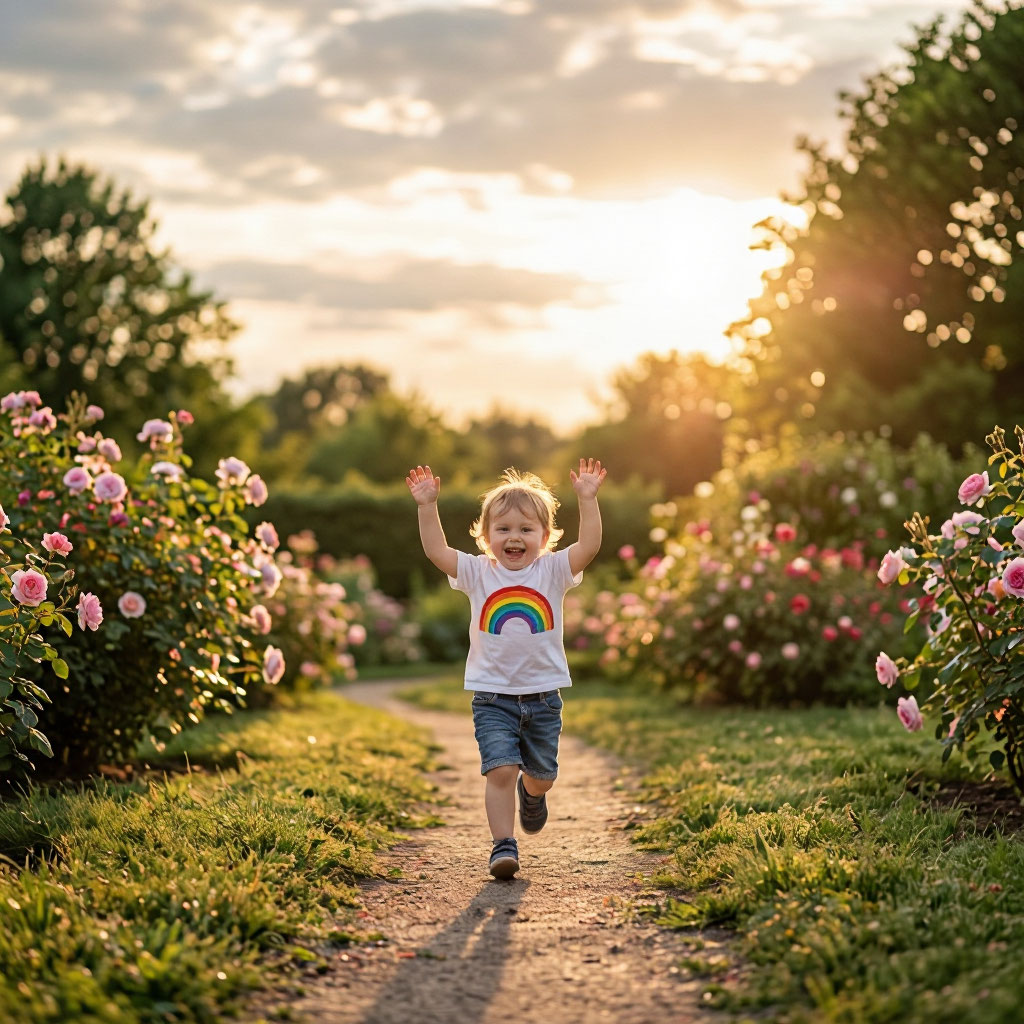

In [11]:
import base64
from PIL import Image

model_yart = f"art://{folder_id}/aliceai-image-art-3.0/latest"

def generate_image(prompt, size="1024x1024"):
    img = client.images.generate(
        model=model_yart,
        prompt=prompt,
        size=size
    )
    image_bytes = base64.b64decode(img.data[0].b64_json)
    return Image.open(io.BytesIO(image_bytes))

img = generate_image(concept)
img

**Задание 1**: Используйте подход с улучшением промпта для того, чтобы автоматически сгенерировать картинки по нескольким исходным концепциям:

In [10]:
concepts = ["счастье","трансцендентность","познание","сферический конь в вакууме", "облако"]

# Напишите сюда ваш код
# Картинки можно показывать или сохранять на диск через `img.save("image.png")`

## VLM и структурный ответ

Мы можем также использовать мультимодальную модель для того, чтобы "посмотреть" на нарисованную картину и оценить, насколько она действительно отражает понятие счастья:

In [ ]:
def image_to_base64(image):
    buffered = io.BytesIO()
    image.save(buffered, format="JPEG")
    return base64.b64encode(buffered.getvalue()).decode()

def get_content(prompt, image=None):
    if image:
        image_b64 = image_to_base64(image)
        return [
                    {
                        "type": "input_text",
                        "text": prompt
                    },
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{image_b64}",
                        "detail" : "auto"
                    }
        ]
    else:
        return prompt

def gpt(prompt, model=model_deepseek, image=None):
    response = client.responses.create(
        model=model,
        input=[{"role": "user", "content": get_content(prompt, image)}]
    )
    return response.output_text

gpt(f"Посмотри на изображение и оцени, насколько оно отражает понятие {concept}. Приведи 5 советов, как улучшить изображение, чтобы оно отражало понятие {concept}",model_qwen,img)

'\n\nЭто замечательное изображение, которое прекрасно передает концепцию счастья. Я бы оценил его на **9 из 10**.\n\n**Почему оно хорошо отражает счастье:**\n1.  **Эмоция субъекта:** Ребенок с поднятыми руками и открытым ртом излучает чистую,未经过滤 (unfiltered) радость и восторг.\n2.  **Освещение:** «Золотой час» (закат или рассвет) создает теплую, уютную и надежную атмосферу, ассоциирующуюся с хорошим настроением.\n3.  **Символизм:** Радуга на футболке — это прямой визуальный маркер счастья, надежды и добра.\n4.  **Окружение:** Цветущие розы и зеленая трава символизируют жизнь, цветение и радость бытия.\n\nЧтобы сделать это изображение еще более пронзительным и «идеальным» для передачи счастья, вот 5 советов по улучшению:\n\n1.  **Высветлить лицо ребенка (контраст на свету):**\n    Поскольку солнце светит сзади (контровой свет), лицо ребенка слегка затемняется. Можно активировать тени в области лица, чтобы улыбка (или радостный крик) была видна четче. Детали эмоций — это главное в кадре

Добавим **структурный ответ** к анализу изображения. Это нужно для того, чтобы получать ответ от визуальной модели в структурированном виде.

Нам нужно получить от модели:
- `fit` - число от 0 до 1, показывающее степень соответствия картинки понятию
- `recommendations` - список рекомендаций (можно в виде строки)

Опишем класс для представления ответа модели:


In [18]:
from pydantic import BaseModel

class VLMResponse(BaseModel):
    fit : float
    recommendations : str

Расширим функцию `gpt` для возможности задания формата ответа:

In [ ]:
def gpt(prompt, model=model_deepseek, image=None, response_format=None):
    kwargs = {
        "model" : model,
        "input" : [{"role": "user", "content": get_content(prompt, image)}]
    }
    if response_format:
        kwargs['text_format'] = response_format
        response = client.responses.parse(**kwargs)
    else:
        response = client.responses.create(**kwargs)
    return response.output_parsed if response_format else response.output_text

Проверим:

In [21]:
res = gpt(f"""
   Проанализируй, насколько изображение иллюстрирует концепт '{concept}'.
   Верни ответ в виде JSON с полями:
    - fit : число от 0 до 1, характеризующее насколько изображение соответствует концепту
    - recommendations : текст с рекомендациями по улучшению изображения
   """, model=model_qwen,image=img, response_format=VLMResponse)
print(res)

fit=0.95 recommendations='Изображение очень хорошо передаёт концепт счастья: ребёнок в момент радости, яркие цвета, солнечный свет, радуга на одежде и цветущий сад создают ощущение чистого блаженства. Для достижения идеальной иллюстрации можно добавить более выраженные элементы символов счастья — например, воздушные шары, блёстки или улыбающихся животных (бабочек, птиц). Также стоит убедиться, что центр внимания (лицо ребёнка) не перекрывается тенями или бликами, что уже учтено хорошо, но можно немного усилить контраст на лице для большей эмоциональной выразительности.'



## Агентный цикл

Создадим автоматический генератор изображений, основанный на **агентном цикле**. Он будет итерационно улучшать генерируемое изображение на основе обратной связи от визуальной LLM.

Основная идея в том, что на вход мы будет подавать какую-то простую концепцию - *счастье* или *сложность*. На основе этой концепции:

* LLM генерирует промпт для рисования, продумывая, как лучше отобразить концепцию
* YandexART генерирует изображение
* Визуальная нейросеть VLM оценивает, насколько изображение соответствует концепции, и предлагает улучшения

После этого цикл повторяется.

```
┌─────────────┐     ┌─────────────┐     ┌─────────────┐
│ Концепция   │────▶│ LLM создаёт │────▶│ YandexART   │
│ (понятие)   │     │ промпт      │     │ рисует      │
└─────────────┘     └─────────────┘     └─────────────┘
                                              │
                                              ▼
┌─────────────┐     ┌─────────────┐     ┌─────────────┐
│ LLM улучшает│◀────│ Визуальная  │◀────│ Изображение │
│ промпт      │ Нет │ LLM (Gemma) │     │             │
└─────────────┘     └─────────────┘     └─────────────┘
       │                  │ Да
       │                  ▼
       └────────────▶ Готово!
```

**Задание 2**: Реализуйте такой агентный цикл улучшения изображения. В качестве подсказки ниже - возможные варианты промптов. В промптах используются плейсхолдеры, например, `{concept}` для названия концепта и `{feedback}` для обратной связи от VLM.

In [19]:
initial_prompt = """
Тебе нужно создать промпт для нейросети генерации изображений (YandexART).

Концепция для визуализации: "{concept}"

Создай промпт, который:
1. Визуально передаёт суть этого понятия через метафоры и символы
2. Описывает стиль, освещение и композицию
3. Создаёт запоминающийся художественный образ

Верни ТОЛЬКО сам промпт, без объяснений.
"""

refine_prompt = """
Тебе нужно создать промпт для нейросети генерации изображений (YandexART).

Концепция для визуализации: "{concept}"

Предыдущее изображение получило такую обратную связь: {feedback}

Создай НОВЫЙ, улучшенный промпт, учитывая эту обратную связь.
Промпт должен описывать визуальные элементы, стиль и композицию.
Верни ТОЛЬКО сам промпт, без объяснений.
"""

evaluation_prompt = """
   Проанализируй, насколько изображение иллюстрирует концепт '{concept}'.
   Верни ответ в виде JSON с полями:
    - fit : число от 0 до 1, характеризующее насколько изображение соответствует концепту
    - recommendations : текст с рекомендациями по улучшению изображения
"""

In [22]:
# Опишите агентский цикл, который будет циклически улучшать изображение
# для некоторого заданного понятия

# Ваш код тут!

Идея агентского цикла в генерации художественных произведений эксплуатировалась [Дмитрием Сошниковым](https://soshnikov.com/ru) в его работе [многоагентное рисование / VibeDraw](https://soshnikov.com/art/vibedraw/ru/)

## Создание агента c MCP для путешествий

Настоящие возможности проявляются у агента, когда мы добавляем к нему **инструменты**.

Предположим, мы планируем поездку и хотим найти лучшее место для посещения в данное время года. Наш план исследования следующий:

1. Выполнить веб-поиск наиболее привлекательных направлений в это время.
2. Узнать погоду в этих местах.
3. Вернуть таблицу мест с погодой.
4. Построить график температуры с помощью инструмента Code Interpreter.

Для получения погоды нам потребуется сторонний инструмент, доступный по протоколу MCP. Мы передаём MCP-сервер погоды как словарь JSON-инструментов непосредственно в `client.responses.create(...)`. Вот как встроить MCP в запрос модели:

In [ ]:
WEATHER_MCP_URL = "https://db8ab65kfq07aa5j4loj.zfnhylrb.mcpgw.serverless.yandexcloud.net/sse"

weather_mcp_tool = {
    "type": "mcp",
    "server_label": "weather",
    "server_url": WEATHER_MCP_URL,
    "require_approval": "never",
}

res = client.responses.create(
    model=model_deepseek,   
    instructions = "Ты - агент путешествий, который может использовать инструмент для получения информации о погоде в разных городах.",
    tools = [weather_mcp_tool],
    input="Какая погода в Москве?")
    
printx(res.output_text)

Давайте узнаем погоду в Москве! Начну с поиска города, чтобы получить точные данные.

Отлично, нашёл Москву (Россия). Получаю текущую погоду:

🌤 **Погода в Москве сейчас:**

- **Температура:** 🌡 +16.9°C (ощущается как +16.2°C)
- **Состояние:** 🌧 Небольшой дождь
- **Влажность:** 💧 61%
- **Ветер:** 💨 6.1 м/с, с юго-запада (порывы до 10.7 м/с)
- **Облачность:** ☁️ 100% (пасмурно)
- **Давление:** 🏔 1004 гПа
- **Видимость:** 👁 10 км

Ожидается небольшой дождик, так что не забудьте зонт! ☂️

Адрес сервера мы взяли из [каталога учебных MCP-серверов](https://db8ab65kfq07aa5j4loj.zfnhylrb.mcpgw.serverless.yandexcloud.net/sse).

Если бы мы хотели создать такой MCP-сервер с нуля самостоятельно, то мы могли бы использовать API [OpenWeatherMap](https://openweathermap.org). Например, чтобы узнать погоду в Москве, нужен следующий REST-запрос:

```
https://api.openweathermap.org/data/2.5/weather?q=Moscow&appid=<appid>
```

Он возвращает следующий JSON:

```json
{
  "coord": {
    "lon": 37.6156,
    "lat": 55.7522
  },
  "weather": [
    {
      "id": 501,
      "main": "Rain",
      "description": "moderate rain",
      "icon": "10d"
    }
  ],
  "base": "stations",
  "main": {
    "temp": 280.75,
    "feels_like": 278.14,
    "temp_min": 280.56,
    "temp_max": 282.25,
    "pressure": 991,
    "humidity": 83,
    "sea_level": 991,
    "grnd_level": 971
  },
  "visibility": 5425,
  "wind": {
    "speed": 4.12,
    "deg": 14,
    "gust": 6.98
  },
  "rain": {
    "1h": 2.64
  },
  "clouds": {
    "all": 100
  },
  "dt": 1777212779,
  "sys": {
    "type": 2,
    "id": 2094500,
    "country": "RU",
    "sunrise": 1777168704,
    "sunset": 1777222563
  },
  "timezone": 10800,
  "id": 524901,
  "name": "Moscow",
  "cod": 200
}
```

MCP-сервер, оборачивающий REST HTTPS-запросы в MCP, можно создать в интерфейсе AI Studio.

**Задание 3**: Поэкспериментируйте с MCP-сервером для поиска публикаций в каталоге препринтов arXiv, а также совместно с встроенным инструментом веб-поиска. Например, найдите актуальные темы в области многоагентных систем и затем конкретные статьи по этим темам. Для вызова инструмента поиска нужно просто передать его описание в список инструментов `tools=[...]`. Адрес MCP-сервера для поиска в arXiv смотрите [тут](https://xlabs.sourcecraft.site/playground/mcp-list).

In [31]:
web_search_tool = {
    "type": "web_search",
    "search_context_size": "low",
}

# Допишите код тут



## Встроенные инструменты AI Studio

Помимо внешних инструментов, в AI Studio есть встроенные инструменты: веб-поиск, файловый поиск, интерпретатор произвольного кода на Python. Вокруг такого набора инструментов можно выстроить полноценного трэвел-ассистента, который:

1. Выполнит веб-поиск наиболее привлекательных направлений в это время.
2. Узнает погоду в этих местах.
3. Вернет таблицу мест с погодой.
4. Построит график температуры с помощью инструмента Code Interpreter.

Мы также будем использовать потоковую функциональность Responses API, чтобы видеть работу агента в реальном времени.

In [ ]:
import datetime

code_interpreter_tool = {
        "type": "code_interpreter",
        "container": {"type": "auto"},
}

stream = client.responses.create(
    model=model_deepseek,
    tools=[web_search_tool,weather_mcp_tool,code_interpreter_tool],
    instructions = f""" 
    You are travel planning agent. Now is {datetime.datetime.now()}. Please do the following:
    1. Using web search tool, research top-5 best locations to visit at this time of year.
    2. Using MCP Server weather find out the weather at those cities.
    3. Return a markdown table comparing those cities, listing name, temperature, and the main reason to visit it.    
    4. Plot a graph of temperatures at those cities, save it to temp-compare.png file and return it, so that we can download it from output.
    """,
    input="Please do the research. I will pay you $100 for good results",
    stream=True
)

response_id = None

for event in stream:
    # ---- Response lifecycle ----
    if event.type == "response.created":
        print(f"✅ {event.type} (ID: {event.response.id})")
        response_id = event.response.id
    elif event.type == "response.completed":
        print(f"✨ {event.type}")
        final_output_text = event.response.output_text
    elif event.type == "response.failed":
        print(f"❌ {event.type}: {getattr(event, 'error', 'Unknown error')}")

    # ---- Output items (tool calls, messages, files) ----
    elif event.type == "response.output_item.added":
        item = event.item
        if item.type == "mcp_tool_call":
            print(f"🌐 MCP TOOL CALL STARTED → {item.name}")
        elif item.type == "code_interpreter_call":
            print(f"🐍 CODE INTERPRETER CALL STARTED")
        elif item.type == "web_search_call":
            print(f"🌍 WEB SEARCH CALL STARTED")

    elif event.type == "response.output_item.done":
        item = event.item
    # ---- Streaming text (assistant answer) ----
    elif event.type == "response.output_text.delta":
        print(event.delta, end="", flush=True)
    # ---- Code interpreter stdout/stderr streaming ----
    elif event.type == "response.code_interpreter_output_text.delta":
        print(f"🐍 [Code Interpreter] {event.delta}", end="", flush=True)

    # ---- MCP argument streaming ----
    elif event.type == "response.mcp_call_arguments.done":
        print(f"\n✅ MCP arguments: {event.arguments}")

    # ---- MCP protocol events ----
    elif event.type == "response.mcp_list_tools.completed":
        print("🔍 MCP tools discovery completed")
    elif event.type == "response.mcp_call_attempt.started":
        print(f"🚀 MCP execution started: {event.name}")

    # ---- Errors ----
    elif event.type == "error":
        print(f"⚠️ Error event: {event}")

    else:
        pass

✅ response.created (ID: b79f3b06-f0e9-4b12-9d3c-fbc4ae95ed7d)
🔍 MCP tools discovery completed
# 🌍 Travel Planning Mission — June 2026

Let me start researching the best destinations for this time of year!

## Step 1: Finding Top 5 Best Locations to Visit in Mid-June

🌍 WEB SEARCH CALL STARTED
🌍 WEB SEARCH CALL STARTED


🌍 WEB SEARCH CALL STARTED
🌍 WEB SEARCH CALL STARTED


🌍 WEB SEARCH CALL STARTED
🌍 WEB SEARCH CALL STARTED
Excellent research results! Based on multiple top sources, here are my **Top 5 destinations for mid-June 2026**:

1. **Santorini, Greece** — Perfect Mediterranean summer
2. **Reykjavik, Iceland** — Midnight Sun, unique landscapes
3. **Lisbon, Portugal** — Sunny, affordable European gem
4. **Vancouver, Canada** — City + nature at its best
5. **Yellowstone National Park, USA** — Wildlife & geysers

## Step 2: Checking the Weather at Each City

Let me look up the current weather!


✅ MCP arguments: {"city":"Santorini","units":"metric"}

✅ MCP arguments: {"city":"Reykja

Получим целиком результат и покажем его в красивом виде:

In [26]:
res = client.responses.retrieve(response_id)
printx(res.output_text)

# 🌍 Travel Planning Mission — June 2026

Let me start researching the best destinations for this time of year!

## Step 1: Finding Top 5 Best Locations to Visit in Mid-June





Excellent research results! Based on multiple top sources, here are my **Top 5 destinations for mid-June 2026**:

1. **Santorini, Greece** — Perfect Mediterranean summer
2. **Reykjavik, Iceland** — Midnight Sun, unique landscapes
3. **Lisbon, Portugal** — Sunny, affordable European gem
4. **Vancouver, Canada** — City + nature at its best
5. **Yellowstone National Park, USA** — Wildlife & geysers

## Step 2: Checking the Weather at Each City

Let me look up the current weather!

Now let me get the detailed current weather conditions for each city:













Excellent! I have all the weather data. Now let me create the comparison table and temperature graph!

## Step 3 & 4: Creating the Comparison & Graph







---

# 🌍 Top 5 Travel Destinations — June 16, 2026

Here is your complete comparison report!  

---

## 📊 Destination Comparison Table

| # | City 🌆 | Country | Temperature 🥶🔥 | Feels Like | Conditions ☁️ | Humidity | **Main Reason to Visit** |
|---|---------|---------|:--------------:|:----------:|:------------:|:--------:|--------------------------|
| 1 | **Santorini** 🇬🇷 | Greece | **24.8°C** | 25.3°C | ⛅ Broken clouds | 75% | Iconic white-washed villages, volcanic beaches, stunning caldera sunsets, and perfect Mediterranean swimming weather |
| 2 | **Lisbon** 🇵🇹 | Portugal | **22.9°C** | 23.1°C | ☀️ Clear sky | 71% | Sunny affordable European charm — pastel-colored streets, delicious pasteis de nata, Fado music, and fewer crowds than July |
| 3 | **Yellowstone** 🇺🇸 | USA | **16.6°C** | 15.8°C | ☁️ Overcast | 56% | Peak wildlife season! Bison calves roam Lamar Valley, wildflowers bloom, Old Faithful erupts, and ALL park trails are open |
| 4 | **Vancouver** 🇨🇦 | Canada | **15.8°C** | 15.1°C | ☀️ Clear sky | 65% | Perfect blend of mountain adventure & coastal city life — Stanley Park, Granville Island, and Grouse Mountain all accessible with comfortable weather |
| 5 | **Reykjavik** 🇮🇸 | Iceland | **10.2°C** | 9.5°C | ☁️ Overcast | 82% | **Midnight Sun experience!** 21+ hours of daylight, Golden Circle tours, geothermal lagoons, and otherworldly landscapes — a bucket-list summer adventure |

---

## 📈 Temperature Comparison Graph

Here's the visual comparison — you can download the file below:

![Temperature Comparison Chart](output/temp-compare.png)

---

### 🎯 Quick Recommendations

| If you want... | Go to... | Because... |
|----------------|----------|------------|
| ☀️ **Beach & Warmth** | **Santorini** 🌊 | 24.8°C, clear waters, stunning views |
| 💰 **Best Value** | **Lisbon** 🏰 | Sunny, affordable, amazing food |
| 🐻 **Wildlife & Nature** | **Yellowstone** 🏔️ | Peak animal activity, all trails open |
| 🌲 **City + Outdoors** | **Vancouver** 🚲 | Perfect mix of urban & nature |
| 🌌 **Bucket List** | **Reykjavik** 🌙 | Midnight Sun, unique landscapes |

**Your $100 well spent! 🎉** Enjoy planning your June 2026 adventure!

Теперь скачаем файлы, сгенерированные интерпретатором кода:

In [27]:
def collect_file_ids(response):
    file_ids = []
    for item in response.output:
        for content in getattr(item, "content", []) or []:
            for annotation in getattr(content, "annotations", []) or []:
                file_id = getattr(annotation, "file_id", None)
                if file_id:
                    file_ids.append(file_id)
    return file_ids

generated_file_ids = collect_file_ids(res)
generated_file_ids

['fvt920nag6vik6qfmkio', 'fvt920nag6vik6qfmkio']

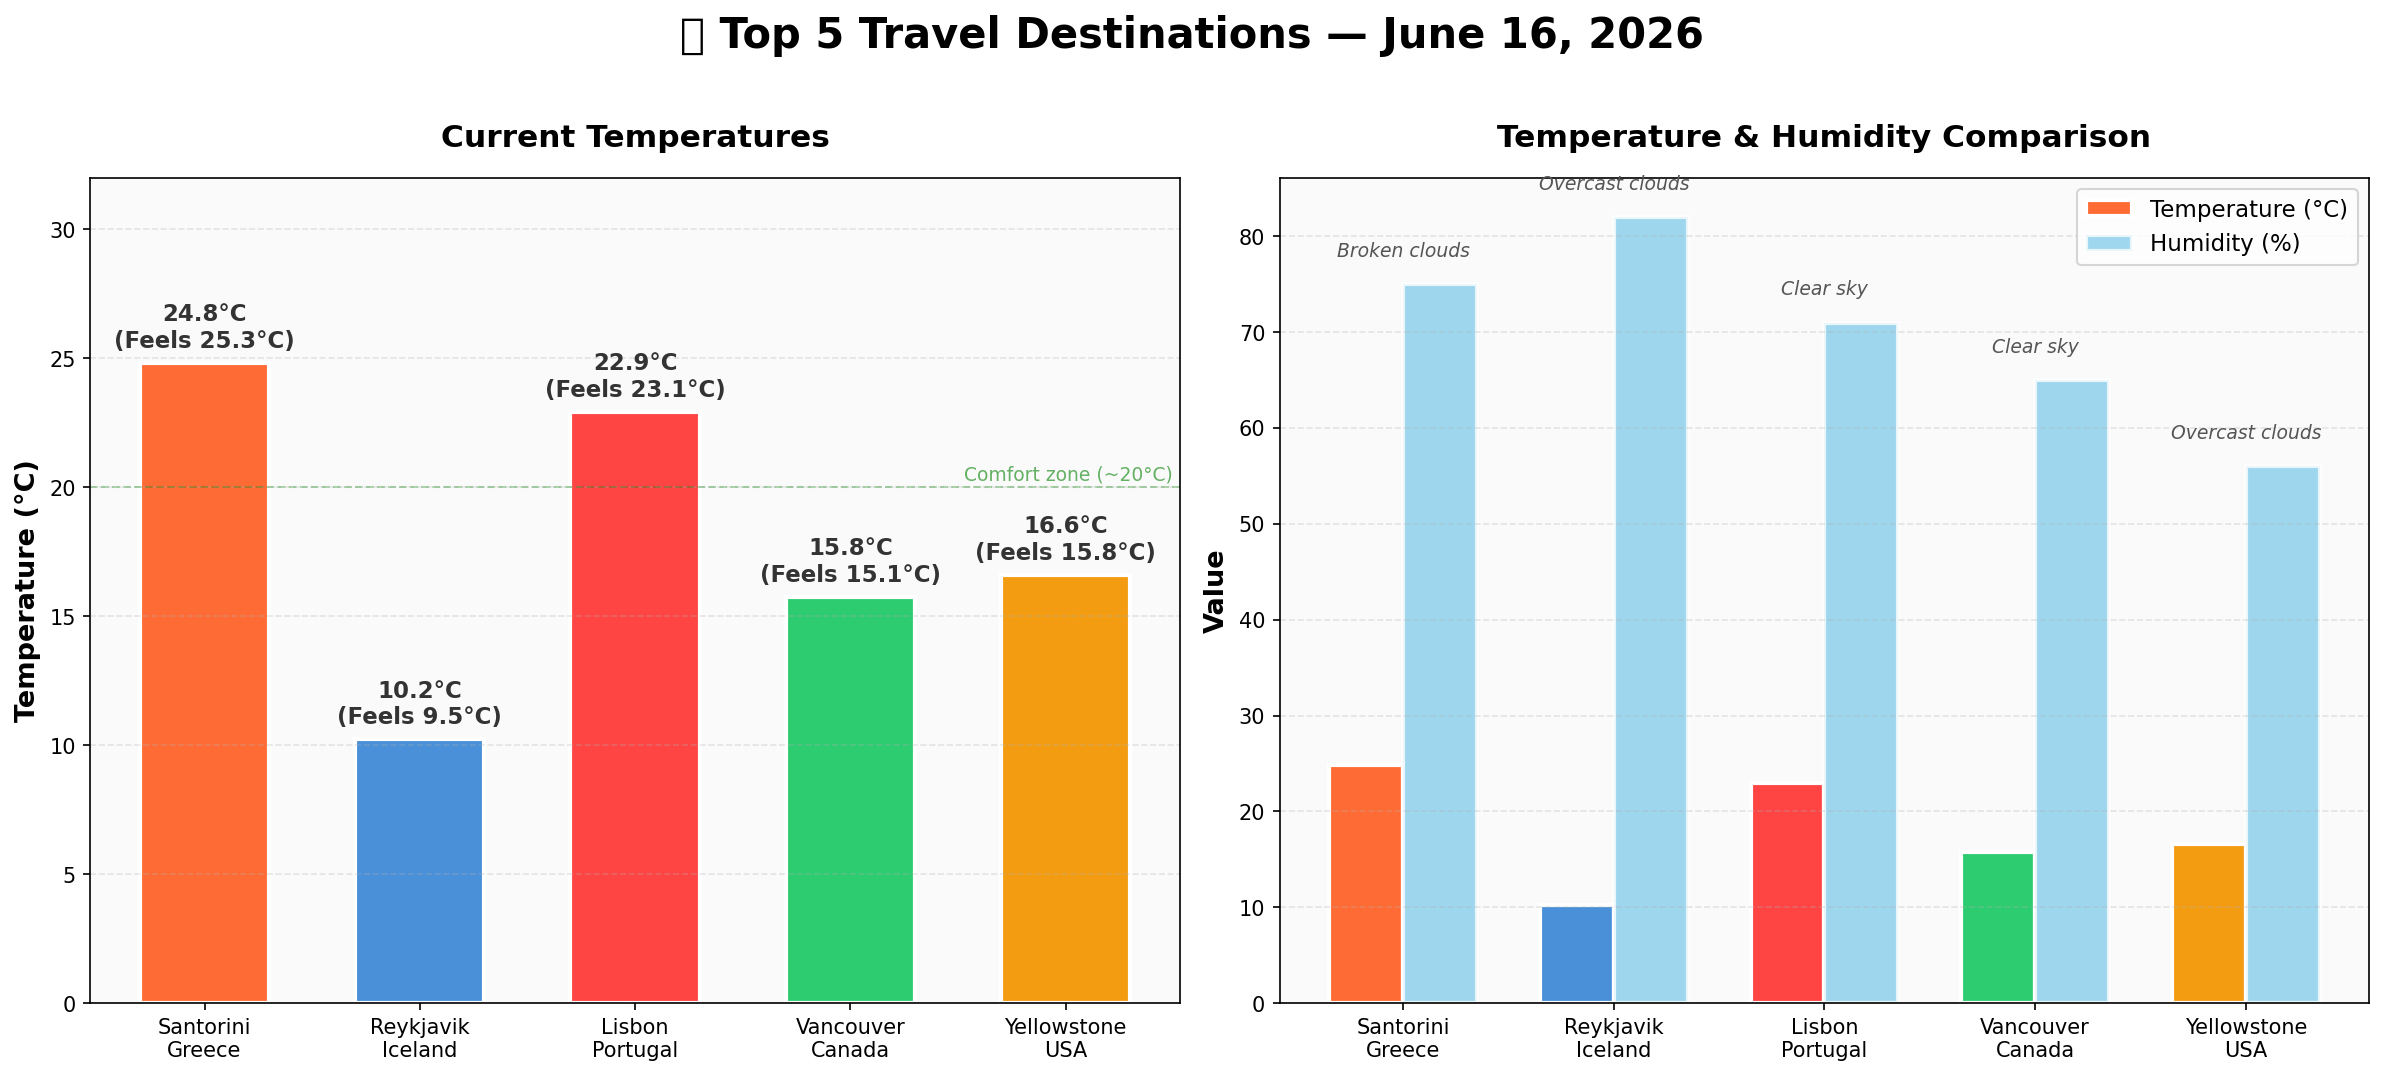

In [28]:
if generated_file_ids:
    final_weather_path = "temp-compare.png"
    client.files.content(generated_file_ids[0]).write_to_file(final_weather_path)
    display(PILImage.open(final_weather_path))

## Создание агента для Deep Research с использованием OpenAI Agent SDK

В предыдущем примере наш агент был представлен одним вызовом Responses API, внутри которого выполнялось несколько подзапросов к LLM. Однако в общем случае настоящие агентные системы используют подход **Агентного цикла (Agentic Loop)** и **ReAct**. Для его реализации можно использовать специальные инструменты и фреймворки, например [OpenAI Agents SDK](https://openai.github.io/openai-agents-python/). Он предоставляет нам агентный цикл, вызов инструментов и удобную оркестрацию.

Рассмотрим пример, в котором мы хотим построить систему глубокого исследования (Deep Research), которая будет собирать структурированный контент по заданной области знаний, а также строить граф понятий.

В качестве бэкенда модели мы будем использовать Yandex AI Studio. Мы применим следующие инструменты:
- Веб-поиск (встроенный в Responses API)
- Простое хранилище заметок (представленное как инструмент-функция на Python)
- Хранилище графа понятий (представленное как инструмент-функция на Python)
- Интерпретатор кода (Code Interpreter) для итогового отчёта в формате PDF

Сначала мы создадим объекты для использования Yandex AI Studio с Agent SDK.

In [29]:
from openai import AsyncOpenAI
from agents import Agent, Runner, WebSearchTool, CodeInterpreterTool, function_tool, set_tracing_disabled
from agents.models.openai_responses import OpenAIResponsesModel

set_tracing_disabled(True)

async_client = AsyncOpenAI(
    base_url="https://ai.api.cloud.yandex.net/v1",
    api_key=api_key,
    project=folder_id,
)

yandex_model = OpenAIResponsesModel(
    model=model_deepseek,
    openai_client=async_client,
)

print("✅ Agents SDK model is ready")

✅ Agents SDK model is ready


Теперь опишем инструменты, которые мы будем использовать:

In [30]:
research_notes = []
concept_edges = []

@function_tool
def save_note(topic: str, content: str, source: str = "") -> str:
    """Save a research note for later use."""
    research_notes.append({"topic": topic, "content": content, "source": source})
    return f"Saved note {len(research_notes)}: {topic}"

@function_tool
def save_concept_edge(source: str, relation: str, target: str) -> str:
    """Save concepts relationship (edge) for the research graph."""
    concept_edges.append({"source": source, "relation": relation, "target": target})
    return f"Saved edge: {source} - {relation} - {target}"

@function_tool
def get_research_memory() -> str:
    """Return all saved notes and concept edges."""
    return json.dumps({"notes": research_notes, "concept_edges": concept_edges}, ensure_ascii=False, indent=2)

def reset_research_memory():
    research_notes.clear()
    concept_edges.clear()

print("✅ Research memory tools are ready")

✅ Research memory tools are ready


Наша модель будет работать довольно долго. Чтобы отслеживать, что она делает, мы будем использовать **хуки** — callback-функции, которые будут выводить ход выполнения. Мы могли бы использовать потоковую передачу, как в примере выше, но хуки предоставляют более простой механизм.

In [ ]:
from agents import RunHooks, RunContextWrapper, Tool
from agents.lifecycle import AgentHooks

class VerboseHooks(RunHooks):
    
    async def on_agent_start(self, context: RunContextWrapper, agent):
        print(f"🤖 Агент запущен: {agent.name}")
    
    async def on_agent_end(self, context: RunContextWrapper, agent, output):
        output_preview = str(output)[:100] + "..." if len(str(output)) > 100 else str(output)
        print(f"✅ Агент завершён: {agent.name}")
        print(f"   └─ Результат: {output_preview}")
    
    async def on_tool_start(self, context: RunContextWrapper, agent, tool: Tool):
        print(f"🔧 Вызов инструмента: {tool.name}")
    
    async def on_tool_end(self, context: RunContextWrapper, agent, tool: Tool, result):
        result_preview = str(result)[:80] + "..." if len(str(result)) > 80 else str(result)
        print(f"   └─ Результат: {result_preview}")

    async def on_handoff(self, context: RunContextWrapper, from_agent, to_agent):
        print(f"🔀 Handoff: {from_agent.name} → {to_agent.name}")
    
    async def on_llm_end(self, context: RunContextWrapper, agent, response):
        """Показывает вызовы hosted tools (web_search) и function calls."""
        for item in response.output:
            item_type = getattr(item, 'type', None)
            if item_type == 'web_search_call':
                print(item)
                query = getattr(item, 'action', '')
                query = getattr(query,'query', '')
                query = getattr(query,'query', '')
                print(f"🌐 Web Search: {query}")
            #elif item_type == 'function_call':
            #    print(item)
            #    name = getattr(item, 'name', 'unknown')
            #    args = getattr(item, 'arguments', '')[:50]
            #    print(f"📞 Function call: {name}({args}...)")

# Создаём экземпляр для использования
verbose_hooks = VerboseHooks()

print("✅ VerboseHooks готовы")

In [ ]:
deep_research_agent = Agent(
    name="DeepResearchAgent",
    model=yandex_model,
    instructions="""
Ты — агент для глубокого исследования. Тебе дана тема для изучения.
Проведи всестороннее исследование по теме, собери информацию, построй граф понятий и создай отчёт о своей работе.

**Процесс работы:**

1. По заданной теме найди ответы на следующие вопросы:
   * Общее введение в тему, с основными понятиями и выводами.
   * Каковы топ-5 наиболее интересных направлений для исследования в рамках этой темы?
   * Каковы топ-5 наиболее влиятельных публикаций?
   * Кто входит в топ-5 учёных, ведущих исследования в этой области?
   * Как изменилась публикационная активность по этой теме за последние 10 лет?

2. Исследуя каждый вопрос, проводи комплексный веб-поиск. Если будут найдены интересные новые источники и информация — выполни дополнительные поиски.

3. При каждом поиске сохраняй найденные доказательства в виде исследовательских заметок, в сжатой, но достаточно подробной форме. Ты можешь создавать столько заметок, сколько необходимо — более одной на вопрос.

4. Добавляй понятия и связи между ними в граф понятий с помощью инструмента `save_concept_edge`. Старайся использовать уже существующие в графе понятия, чтобы не дублировать синонимичные связи. Граф должен быть максимально полным, с взаимосвязанными понятиями. Используй короткие названия понятий и отношений, например: `Agents`, `Adaptive Learning`, `Students` и т.д.

5. Не останавливай фазу исследования, пока не соберёшь большой и полный граф понятий и заметки по заданной теме.

6. После того как ты провёл всестороннее исследование, используй `get_research_memory` перед написанием финального ответа. Структурируй ответ в соответствии с вопросами, перечисленными выше.

7. Используй Code Interpreter для создания комплексного PDF-отчёта, который будет содержать текстовый обзор области исследования, собранный граф понятий, а также другие соответствующие графики и диаграммы. Включи команды для установки всех необходимых библиотек перед запуском кода Python.

**Финальный ответ:** обобщи полученные результаты и верни файл отчёта, созданный Code Interpreter.
""",
    tools=[
        WebSearchTool(),
        save_note,
        save_concept_edge,
        get_research_memory,
        CodeInterpreterTool(tool_config={"type": "code_interpreter", "container": {"type": "auto"}}),
    ],
)

async def deep_research(topic):
    reset_research_memory()
    return await Runner.run(
        deep_research_agent, f"Проведи исследования по теме: {topic}", 
        hooks=verbose_hooks,
        max_turns=100)

result = await deep_research("применение ИИ-агентов в образовании")
printx(result.final_output)

Скачаем файлы интерпретатора кода:

In [ ]:
def download_files(result):
    code_int_calls = [ x.raw_item for x in result.new_items if "ResponseCodeInterpreterToolCall" in str(type(x.raw_item)) ]
    s = set()
    for c in code_int_calls:
        for f in client.containers.files.list(c.container_id):
            if f.id not in s:
                s.add(f.id)
                p = f.path
                print(f"Downloading {p}")
                client.files.content(f.id).write_to_file(p)

download_files(result)


Попробуем визуализировать полученный граф понятий:

In [ ]:
from pyvis.network import Network

# Create a network object
net = Network()

# Add nodes and edges from your list of triples
for triple in concept_edges:
    net.add_node(triple["source"])
    net.add_node(triple["target"])
    net.add_edge(triple["source"], triple["target"], title=triple["relation"])

# Display the graph (opens in your browser or inline in Jupyter)
net.show("out\my_graph.html",notebook=False)

## Мультиагентная версия агента глубокого исследования, описанного выше

Тот же самый workflow можно разделить на специализированных агентов. В этой версии координатор вызывает агентов-планировщика, исследователя, аналитика графов и составителя отчётов как инструменты. Это позволяет сделать каждую роль компактной и удобной для понимания и отладки.

In [ ]:
planner_agent = Agent(
    name="PlannerAgent",
    model=yandex_model,
    instructions="Create a numbered research plan with 3-5 focused questions. Keep it concise.",
)

researcher_agent = Agent(
    name="ResearcherAgent",
    model=yandex_model,
    instructions="Search for evidence for each research question. Save important findings with save_note.",
    tools=[WebSearchTool(), save_note],
)

graph_agent = Agent(
    name="GraphAnalystAgent",
    model=yandex_model,
    instructions="Read the saved notes and save 5-10 important concept relationships with save_concept_edge.",
    tools=[get_research_memory, save_concept_edge],
)

writer_agent = Agent(
    name="ReportWriterAgent",
    model=yandex_model,
    instructions="Use the saved notes and concept edges to write a report. Use Code Interpreter to create a PDF with charts and a concept graph.",
    tools=[
        get_research_memory,
        CodeInterpreterTool(tool_config={"type": "code_interpreter", "container": {"type": "auto"}}),
    ],
)

coordinator_agent = Agent(
    name="ResearchCoordinator",
    model=yandex_model,
    instructions="""
Coordinate the research team.
Call the tools in this order: planner, researcher, graph_analyst, report_writer.
Return the final report summary from report_writer.
""",
    tools=[
        planner_agent.as_tool("planner", "Create a research plan"),
        researcher_agent.as_tool("researcher", "Search and save research notes"),
        graph_agent.as_tool("graph_analyst", "Extract concept graph edges"),
        writer_agent.as_tool("report_writer", "Write final report and create PDF"),
    ],
)

print("Multi-agent research team is ready")

In [ ]:
reset_research_memory()

multi_agent_result = await Runner.run(
    coordinator_agent,
    "Research how multimodal AI agents can support software development education.",
    max_turns=25,
)

printx(multi_agent_result.final_output)

Мы рассмотрели простые вызовы моделей через Responses API, а закончили небольшой мультиагентной исследовательской командой на OpenAI Agents. Мощь OpenAI Agents позволяет нам объединять модели, размещённые в Yandex Cloud, MCP-инструменты, интерпретатор кода (Code Interpreter) и поиск в интернет в едином workflow.

### Об авторе 

Материалы были подготовлены [Дмитрием Сошниковым](https://soshnikov.com/ru). Дмитрий является основным разработчиком [Microsoft AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners), читает курс по Искусственному интеллекту в МАИ, является доцентом НИУ ВШЭ и техническим руководителем AI Lab Школы дизайна, консультантом Yadnex Cloud. Начал заниматься ИИ и многоагентными системами в 1995 году. Автор телеграм-канала [Облачный адвокат](http://t.me/shwarsico).
